<a href="https://colab.research.google.com/github/fbyprl29/Project-UMKM-Tukang-Marinasi/blob/main/Analisis_Data_Penjualan_untuk_Mendukung_Strategi_Ekspansi_Pasar_UMKM_Tukang_Marinasi_Menggunakan_Python.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [3]:
from google.colab import files

uploaded = files.upload()

Saving Tukang_Marinasi_Data Transaksi.csv to Tukang_Marinasi_Data Transaksi (1).csv


In [8]:
df = pd.read_csv("Tukang_Marinasi_Data Transaksi (1).csv")

df.head()

,Order_ID,Tanggal,Customer_ID,Produk,Wilayah,Segmen_Pelanggan,Kanal_Penjualan,Jumlah_Produk,Harga_Satuan,Total_Penjualan,Tipe_Pelanggan,Metode_Pembayaran,Status_Data
0,ORD-119,2026-07-20 00:00:00,CUST-041,Paket Hemat,Jakarta Selatan,Komunitas/Organisasi,WhatsApp,7,35000,245000,Repeat,Cash,DUMMY
1,ORD-128,2026-07-20 00:00:00,CUST-072,Ayam Blackpepper,Jakarta Timur,Mahasiswa,Offline/Event,3,21000,63000,Repeat,Transfer,DUMMY
2,ORD-045,2026-07-21 00:00:00,CUST-079,Ayam BBQ,Depok,Mahasiswa,Instagram,3,20000,60000,Repeat,E-Wallet,DUMMY
3,ORD-121,2026-07-21 00:00:00,CUST-076,Ayam BBQ,Jakarta Selatan,Mahasiswa,Teman/Referensi,4,20000,80000,Repeat,Cash,DUMMY
4,ORD-136,2026-07-22 00:00:00,CUST-028,Ayam Blackpepper,Jakarta Barat,Mahasiswa,WhatsApp,2,21000,42000,Repeat,Transfer,DUMMY


In [9]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 13 columns):
 #   Column             Non-Null Count  Dtype 
---  ------             --------------  ----- 
 0   Order_ID           150 non-null    object
 1   Tanggal            150 non-null    object
 2   Customer_ID        150 non-null    object
 3   Produk             150 non-null    object
 4   Wilayah            150 non-null    object
 5   Segmen_Pelanggan   150 non-null    object
 6   Kanal_Penjualan    150 non-null    object
 7   Jumlah_Produk      150 non-null    int64 
 8   Harga_Satuan       150 non-null    int64 
 9   Total_Penjualan    150 non-null    int64 
 10  Tipe_Pelanggan     150 non-null    object
 11  Metode_Pembayaran  150 non-null    object
 12  Status_Data        150 non-null    object
dtypes: int64(3), object(10)
memory usage: 15.4+ KB


In [10]:
df = df.drop(columns=['Status_Data'])
display(df.head())

,Order_ID,Tanggal,Customer_ID,Produk,Wilayah,Segmen_Pelanggan,Kanal_Penjualan,Jumlah_Produk,Harga_Satuan,Total_Penjualan,Tipe_Pelanggan,Metode_Pembayaran
0,ORD-119,2026-07-20 00:00:00,CUST-041,Paket Hemat,Jakarta Selatan,Komunitas/Organisasi,WhatsApp,7,35000,245000,Repeat,Cash
1,ORD-128,2026-07-20 00:00:00,CUST-072,Ayam Blackpepper,Jakarta Timur,Mahasiswa,Offline/Event,3,21000,63000,Repeat,Transfer
2,ORD-045,2026-07-21 00:00:00,CUST-079,Ayam BBQ,Depok,Mahasiswa,Instagram,3,20000,60000,Repeat,E-Wallet
3,ORD-121,2026-07-21 00:00:00,CUST-076,Ayam BBQ,Jakarta Selatan,Mahasiswa,Teman/Referensi,4,20000,80000,Repeat,Cash
4,ORD-136,2026-07-22 00:00:00,CUST-028,Ayam Blackpepper,Jakarta Barat,Mahasiswa,WhatsApp,2,21000,42000,Repeat,Transfer


In [11]:
df.shape

(150, 12)

In [12]:
df.isnull().sum()

,0
Order_ID,0
Tanggal,0
Customer_ID,0
Produk,0
Wilayah,0
Segmen_Pelanggan,0
Kanal_Penjualan,0
Jumlah_Produk,0
Harga_Satuan,0
Total_Penjualan,0


In [13]:
df.duplicated().sum()

np.int64(0)

In [14]:
df["Tanggal"] = pd.to_datetime(df["Tanggal"])

In [15]:
df["Minggu"] = df["Tanggal"].dt.to_period("W").astype(str)

In [16]:
total_revenue = df["Total_Penjualan"].sum()
total_produk = df["Jumlah_Produk"].sum()
total_transaksi = df["Order_ID"].nunique()
pelanggan_unik = df["Customer_ID"].nunique()

print("Total Revenue:", total_revenue)
print("Total Produk Terjual:", total_produk)
print("Total Transaksi:", total_transaksi)
print("Jumlah Customer:", pelanggan_unik)

Total Revenue: 9663000
Total Produk Terjual: 441
Total Transaksi: 150
Jumlah Customer: 68


In [17]:
weekly_sales = (
    df.groupby("Minggu")
      .agg(
          Revenue=("Total_Penjualan", "sum"),
          Produk=("Jumlah_Produk", "sum"),
          Transaksi=("Order_ID", "nunique")
      )
      .reset_index()
)

weekly_sales

,Minggu,Revenue,Produk,Transaksi
0,2026-07-20/2026-07-26,836000,37,15
1,2026-07-27/2026-08-02,1426000,57,20
2,2026-08-03/2026-08-09,546000,25,11
3,2026-08-10/2026-08-16,930000,45,16
4,2026-08-17/2026-08-23,1840000,75,25
5,2026-08-24/2026-08-30,1418000,71,25
6,2026-08-31/2026-09-06,1124000,56,16
7,2026-09-07/2026-09-13,1543000,75,22


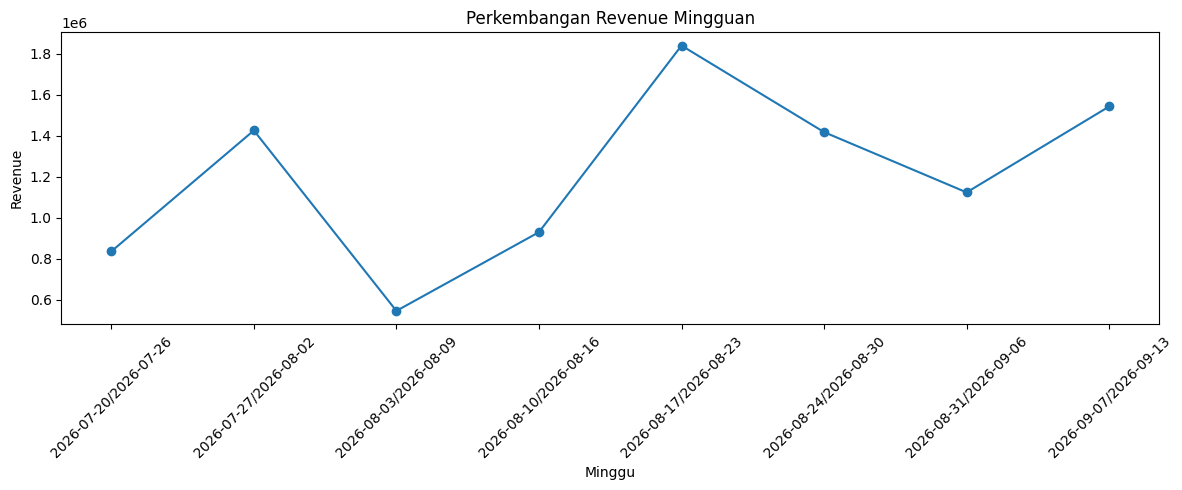

In [18]:
plt.figure(figsize=(12,5))

plt.plot(
    weekly_sales["Minggu"],
    weekly_sales["Revenue"],
    marker="o"
)

plt.title("Perkembangan Revenue Mingguan")
plt.xlabel("Minggu")
plt.ylabel("Revenue")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [19]:
weekly_sales["Growth (%)"] = (
    weekly_sales["Revenue"]
    .pct_change()
    .mul(100)
)

weekly_sales

,Minggu,Revenue,Produk,Transaksi,Growth (%)
0,2026-07-20/2026-07-26,836000,37,15,NaN
1,2026-07-27/2026-08-02,1426000,57,20,70.574163
2,2026-08-03/2026-08-09,546000,25,11,-61.711080
3,2026-08-10/2026-08-16,930000,45,16,70.329670
4,2026-08-17/2026-08-23,1840000,75,25,97.849462
5,2026-08-24/2026-08-30,1418000,71,25,-22.934783
6,2026-08-31/2026-09-06,1124000,56,16,-20.733427
7,2026-09-07/2026-09-13,1543000,75,22,37.277580


In [20]:
product_analysis = (
    df.groupby("Produk")
      .agg(
          Produk_Terjual=("Jumlah_Produk", "sum"),
          Revenue=("Total_Penjualan", "sum"),
          Transaksi=("Order_ID", "nunique")
      )
      .sort_values("Revenue", ascending=False)
)

product_analysis

,Produk_Terjual,Revenue,Transaksi
Produk,,,
Paket Hemat,67,2345000,20
Ayam BBQ,108,2155000,37
Ayam Blackpepper,101,2105000,38
Ayam Pedas,96,1821000,34
Ayam Original,69,1237000,21


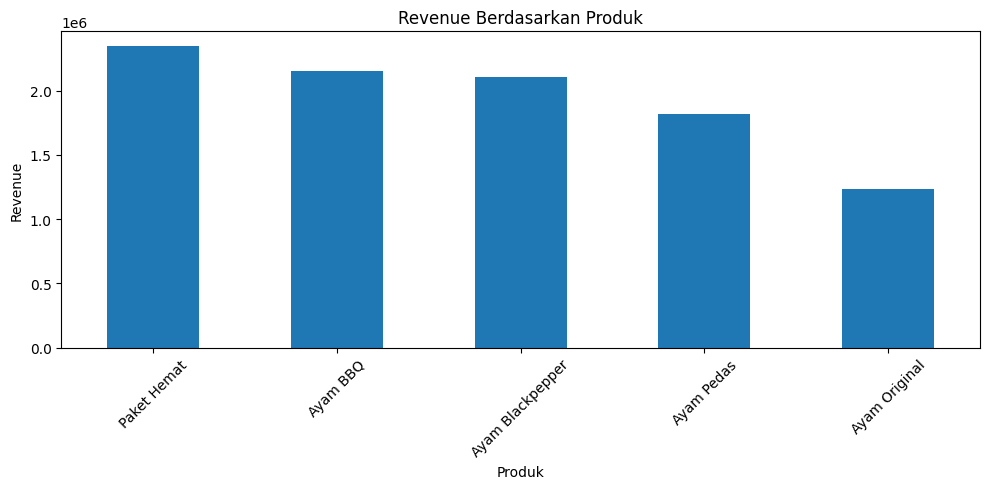

In [21]:
product_analysis["Revenue"].plot(
    kind="bar",
    figsize=(10,5)
)

plt.title("Revenue Berdasarkan Produk")
plt.xlabel("Produk")
plt.ylabel("Revenue")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [22]:
regional_analysis = (
    df.groupby("Wilayah")
      .agg(
          Produk_Terjual=("Jumlah_Produk", "sum"),
          Revenue=("Total_Penjualan", "sum"),
          Transaksi=("Order_ID", "nunique")
      )
      .sort_values("Revenue", ascending=False)
)

regional_analysis

,Produk_Terjual,Revenue,Transaksi
Wilayah,,,
Jakarta Selatan,84,1963000,29
Bogor,65,1489000,18
Depok,65,1432000,24
Tangerang,63,1430000,19
Jakarta Timur,62,1293000,20
Bekasi,42,828000,20
Jakarta Barat,32,672000,12
Jakarta Pusat,28,556000,8


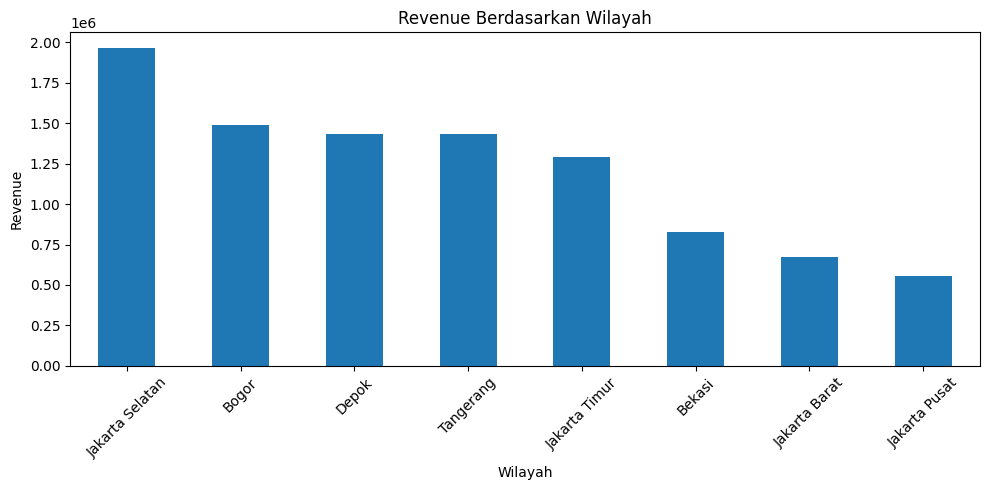

In [23]:
regional_analysis["Revenue"].plot(
    kind="bar",
    figsize=(10,5)
)

plt.title("Revenue Berdasarkan Wilayah")
plt.xlabel("Wilayah")
plt.ylabel("Revenue")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [24]:
regional_analysis.head(3)

,Produk_Terjual,Revenue,Transaksi
Wilayah,,,
Jakarta Selatan,84,1963000,29
Bogor,65,1489000,18
Depok,65,1432000,24


Analisis Segmen Pelanggan

In [25]:
segment_analysis = (
    df.groupby("Segmen_Pelanggan")
      .agg(
          Produk_Terjual=("Jumlah_Produk", "sum"),
          Revenue=("Total_Penjualan", "sum"),
          Transaksi=("Order_ID", "nunique")
      )
      .sort_values("Revenue", ascending=False)
)

segment_analysis

,Produk_Terjual,Revenue,Transaksi
Segmen_Pelanggan,,,
Mahasiswa,175,3659000,70
Karyawan,107,2537000,36
Komunitas/Organisasi,85,1978000,17
Rumah Tangga,74,1489000,27


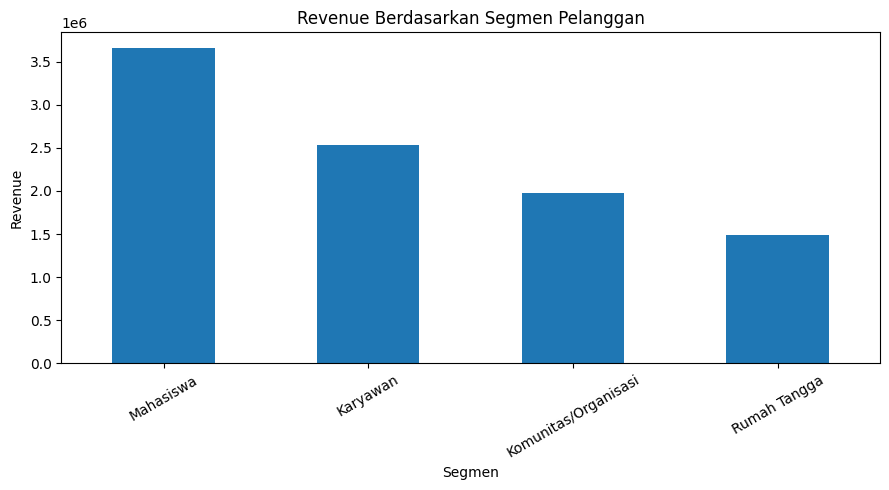

In [26]:
segment_analysis["Revenue"].plot(
    kind="bar",
    figsize=(9,5)
)

plt.title("Revenue Berdasarkan Segmen Pelanggan")
plt.xlabel("Segmen")
plt.ylabel("Revenue")
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

**Analisis Chanell Penjualan**

In [27]:
channel_analysis = (
    df.groupby("Kanal_Penjualan")
      .agg(
          Produk_Terjual=("Jumlah_Produk", "sum"),
          Revenue=("Total_Penjualan", "sum"),
          Transaksi=("Order_ID", "nunique")
      )
      .sort_values("Revenue", ascending=False)
)

channel_analysis

,Produk_Terjual,Revenue,Transaksi
Kanal_Penjualan,,,
WhatsApp,167,3552000,57
TikTok,87,2007000,26
Instagram,94,1976000,32
Teman/Referensi,58,1335000,22
Offline/Event,35,793000,13


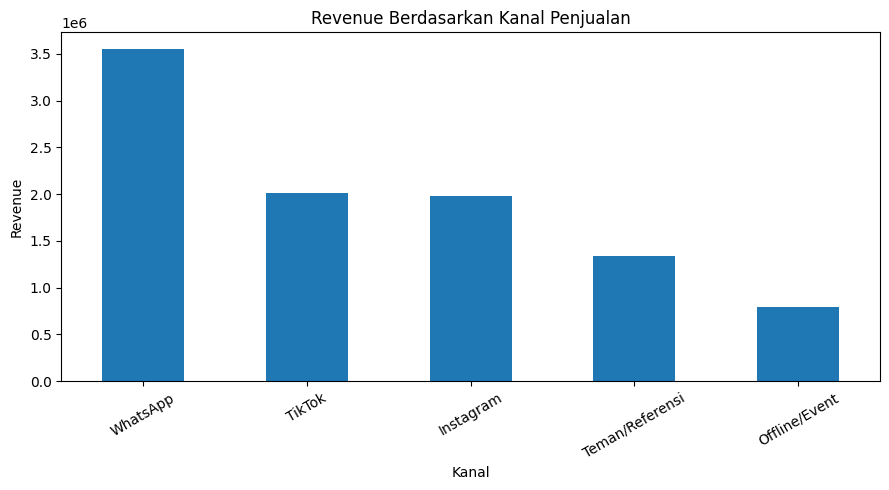

In [28]:
channel_analysis["Revenue"].plot(
    kind="bar",
    figsize=(9,5)
)

plt.title("Revenue Berdasarkan Kanal Penjualan")
plt.xlabel("Kanal")
plt.ylabel("Revenue")
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

Analisis Pelanggan Baru VS Pelanggan Tetap

In [29]:
customer_analysis = (
    df.groupby("Tipe_Pelanggan")
      .agg(
          Transaksi=("Order_ID", "nunique"),
          Produk_Terjual=("Jumlah_Produk", "sum"),
          Revenue=("Total_Penjualan", "sum")
      )
)

customer_analysis

,Transaksi,Produk_Terjual,Revenue
Tipe_Pelanggan,,,
Baru,71,208,4495000
Repeat,79,233,5168000


Cari Perluasan Wilayah

In [30]:
expansion = regional_analysis.copy()

expansion["Revenue_Score"] = (
    expansion["Revenue"] / expansion["Revenue"].max() * 100
)

expansion["Volume_Score"] = (
    expansion["Produk_Terjual"] / expansion["Produk_Terjual"].max() * 100
)

expansion["Priority_Score"] = (
    expansion["Revenue_Score"] * 0.6 +
    expansion["Volume_Score"] * 0.4
)

expansion.sort_values(
    "Priority_Score",
    ascending=False
)

,Produk_Terjual,Revenue,Transaksi,Revenue_Score,Volume_Score,Priority_Score
Wilayah,,,,,,
Jakarta Selatan,84,1963000,29,100.000000,100.000000,100.000000
Bogor,65,1489000,18,75.853286,77.380952,76.464352
Depok,65,1432000,24,72.949567,77.380952,74.722121
Tangerang,63,1430000,19,72.847682,75.000000,73.708609
Jakarta Timur,62,1293000,20,65.868569,73.809524,69.044951
Bekasi,42,828000,20,42.180336,50.000000,45.308202
Jakarta Barat,32,672000,12,34.233316,38.095238,35.778085
Jakarta Pusat,28,556000,8,28.323994,33.333333,30.327730


In [31]:
expansion.head(3)

,Produk_Terjual,Revenue,Transaksi,Revenue_Score,Volume_Score,Priority_Score
Wilayah,,,,,,
Jakarta Selatan,84,1963000,29,100.000000,100.000000,100.000000
Bogor,65,1489000,18,75.853286,77.380952,76.464352
Depok,65,1432000,24,72.949567,77.380952,74.722121


## Rekomendasi Bisnis

Berdasarkan analisis data transaksi tukang marinasi,Rekomendasi bisnis yang perlu dipertimbangkan yaitu:

### 1. Strategi Produk
*   **Fokus pada Produk Unggulan:** Produk seperti "Paket Hemat", "Ayam BBQ", dan "Ayam Blackpepper" menunjukkan revenue tertinggi jadi tingkatkan promosi, stok produk, atau mengembangkan varian baru dari produk-produk ini.
*   **Evaluasi Produk Berkinerja Rendah:** "Ayam Original" memiliki revenue terendah. Lakukan analisis lebih lanjut mengapa produk ini kurang diminati. Apakah perlu penyesuaian harga, promosi, atau bahkan reformulasi produk?

### 2. Strategi Wilayah & Ekspansi
*   **Prioritaskan Jakarta Selatan, Bogor, dan Depok:** Wilayah ini menunjukkan skor prioritas tertinggi untuk ekspansi berdasarkan pendapatan dan volume penjualan. Alokasikan sumber daya pemasaran dan distribusi lebih banyak ke area ini untuk memaksimalkan potensi pertumbuhan.
*   **Identifikasi Peluang di Wilayah Lain:** Meskipun Jakarta Pusat dan Jakarta Barat memiliki skor prioritas lebih rendah saat ini, tetap pantau perkembangannya dan cari strategi unik untuk menembus pasar tersebut, mungkin dengan promosi khusus atau penawaran produk yang disesuaikan.

### 3. Strategi Pemasaran & Penjualan
*   **Optimalkan Kanal WhatsApp:** WhatsApp adalah kanal penjualan dengan kontribusi revenue tertinggi. Pertimbangkan untuk menginvestasikan lebih banyak pada fitur otomatisasi, program loyalitas, atau tim penjualan khusus WhatsApp.
*   **Manfaatkan Potensi TikTok dan Instagram:** Kedua platform ini juga memberikan kontribusi yang signifikan. Tingkatkan konten visual yang menarik, kolaborasi dengan influencer, atau adakan live shopping untuk menarik lebih banyak pelanggan.
*   **Targetkan Segmen Mahasiswa dan Karyawan:** Kedua segmen ini merupakan penyumbang revenue terbesar. Kembangkan promosi atau paket produk khusus yang menarik bagi daya beli dan kebutuhan mereka.

### 4. Manajemen Pelanggan
*   **Perkuat Loyalitas Pelanggan Ulang (Repeat Customer):** Pelanggan ulang menyumbang revenue yang lebih besar dibandingkan pelanggan baru. Pertahankan dan tingkatkan program loyalitas, diskon khusus, atau layanan pelanggan yang eksklusif untuk mendorong pembelian berulang.
*   **Tingkatkan Konversi Pelanggan Baru:** Lakukan strategi akuisisi yang efektif untuk mengubah pelanggan baru menjadi pelanggan ulang, misalnya dengan penawaran pembelian kedua atau program referral.

### 5. Analisis Tren Mingguan
*   **Analisis Fluktuasi Revenue Mingguan:** Perhatikan pola naik turunnya revenue mingguan (misalnya, adanya peningkatan signifikan di minggu 4 dan 7, lalu penurunan di minggu 2 dan 6). Coba pahami faktor-faktor di balik fluktuasi ini (misalnya, hari libur, promosi, event khusus) untuk mengoptimalkan perencanaan dan persediaan.

In [32]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive
